# Multi-Agent Deep Research for Cat Nutrition and Obesity

Deep research is not one enormous prompt. It is a composition of familiar patterns:

```text
scope -> delegate -> search -> verify -> write -> audit -> evaluate
```

In this notebook, every reasoning actor is built with LangChain's `create_agent`.
A small LangGraph workflow controls the lifecycle, parallel-friendly delegation,
optional human clarification, persistence, and deterministic checks.

The worked example asks:

> What does current evidence say about preventing and safely managing obesity in adult indoor cats?

This is an educational research workflow. It does not diagnose an animal or create
an individualized feeding or weight-loss plan.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain when multiple agents improve context isolation and role specialization.
- Build named `create_agent` workers and expose them as high-level tools.
- Use structured outputs as contracts between research stages.
- Combine agentic loops with a deterministic LangGraph workflow.
- Pause and resume a workflow with `interrupt()` and `Command(resume=...)`.
- Track source URLs through research, verification, writing, and citation auditing.
- Reason about research quality, latency, and API cost as explicit design tradeoffs.


## Table of Contents

- **Breakout Room #1: Specialized Agents and Delegation**
  - Task 1: Environment Setup
  - Task 2: Define Typed Handoff Contracts
  - Task 3: Configure Tavily Search and Extract
  - Task 4: Build Specialized Research Workers
  - Task 5: Wrap Workers as Supervisor Tools
  - Task 6: Build the Research Supervisor
  - Activity #1: Add a New Specialist
- **Breakout Room #2: End-to-End Deep Research Workflow**
  - Task 7: Build the Scoper and Clarification Path
  - Task 8: Build Verification, Writing, and Evaluation Agents
  - Task 9: Define LangGraph State and Nodes
  - Task 10: Compile, Visualize, and Stream the Workflow
  - Task 11: Audit Citations Deterministically
  - Task 12: Run the Full Deep Research System
  - Activity #2: Compare Research Depth and Cost
  - Advanced Build: Add a Local-Corpus Specialist


---
# Breakout Room #1
## Specialized Agents and Delegation

A multi-agent system is useful when independent actors need different prompts,
tools, context, or optimization targets.

Our supervisor does not search the web directly. It delegates bounded research
tasks to workers and receives compact, typed findings. This keeps low-level search
traces out of the supervisor's context.


## Task 1: Environment Setup

From the `04_Multi_Agent_Systems` folder:

```bash
uv sync
```

Then select the environment created by uv as this notebook's kernel.

Required accounts:

- OpenAI API
- Tavily API

LangSmith tracing is optional but strongly recommended for inspecting nested agents.


### Imports


In [1]:
from __future__ import annotations

import json
import os
import re
from datetime import date
from getpass import getpass
from typing import Literal, TypedDict
from urllib.parse import urlsplit, urlunsplit

from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain.agents.middleware import (
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
)
from langchain.messages import ToolMessage
from langchain.tools import tool
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilyExtract, TavilySearch

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

### API Keys, Models, and Research Budgets

The environment variables make the notebook easy to tune without editing code.
Research depth is an application policy, not a mysterious property of the model.

`AIM_SEARCH_CALL_LIMIT` limits Tavily searches per worker invocation.
`AIM_WORKER_MODEL_CALL_LIMIT` bounds each worker's ReAct loop.


In [2]:
# Load environment variables from .env file
load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass("Tavily API Key: ")

os.environ.setdefault(
    "LANGSMITH_PROJECT",
    "aim-session-4-multi-agent-deep-research",
)

TODAY = date.today().isoformat()
CHAT_MODEL_NAME = os.environ.get("AIM_CHAT_MODEL", "gpt-5.4-mini")
WRITER_MODEL_NAME = os.environ.get("AIM_WRITER_MODEL", CHAT_MODEL_NAME)
SEARCH_DEPTH = os.environ.get("AIM_SEARCH_DEPTH", "advanced")
SEARCH_CALL_LIMIT = int(os.environ.get("AIM_SEARCH_CALL_LIMIT", "3"))
EXTRACT_CALL_LIMIT = int(os.environ.get("AIM_EXTRACT_CALL_LIMIT", "2"))
WORKER_MODEL_CALL_LIMIT = int(
    os.environ.get("AIM_WORKER_MODEL_CALL_LIMIT", "8")
)

llm = ChatOpenAI(model=CHAT_MODEL_NAME)
writer_llm = ChatOpenAI(model=WRITER_MODEL_NAME)

print(f"Date: {TODAY}")
print(f"General model: {CHAT_MODEL_NAME}")
print(f"Writer model: {WRITER_MODEL_NAME}")
print(f"Search depth: {SEARCH_DEPTH}")
print(f"Search calls per worker: {SEARCH_CALL_LIMIT}")
print(f"LangSmith tracing: {os.environ.get('LANGSMITH_TRACING', 'false')}")

Date: 2026-06-11
General model: gpt-5.4-mini
Writer model: gpt-5.4-mini
Search depth: advanced
Search calls per worker: 4
LangSmith tracing: true


## Task 2: Define Typed Handoff Contracts

Free-form prose is difficult to validate and pass between application stages.
Pydantic models make the handoff contracts explicit.

Notice that source URLs are first-class data. The report writer will not be allowed
to invent a new source that did not survive verification.


In [3]:
SpecialistName = Literal["guidelines", "evidence", "methodology"]
ConfidenceLevel = Literal["high", "medium", "low"]


class ResearchTask(BaseModel):
    task_id: str = Field(description="Stable short identifier such as task-1")
    question: str = Field(description="Focused research question for one worker")
    specialist: SpecialistName
    rationale: str


class ResearchBrief(BaseModel):
    title: str
    objective: str
    audience: str
    scope_in: list[str]
    scope_out: list[str]
    safety_constraints: list[str]
    tasks: list[ResearchTask] = Field(min_length=3, max_length=3)


class ScopeDecision(BaseModel):
    needs_clarification: bool
    clarification_question: str | None = None
    assumptions: list[str] = Field(default_factory=list)
    brief: ResearchBrief | None = None


class SourceRecord(BaseModel):
    url: str
    title: str
    publisher: str
    published_date: str | None = None
    source_type: Literal[
        "guideline",
        "peer_reviewed",
        "government",
        "university",
        "professional_org",
        "other",
    ]
    authority_reason: str
    relevant_excerpt: str
    accessed_on: str


class ClaimRecord(BaseModel):
    claim: str
    source_urls: list[str] = Field(min_length=1)
    confidence: ConfidenceLevel
    caveat: str


class ResearchFindings(BaseModel):
    task_id: str
    specialist: SpecialistName
    summary: str
    sources: list[SourceRecord] = Field(default_factory=list)
    claims: list[ClaimRecord] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    errors: list[str] = Field(default_factory=list)


class ResearchDossier(BaseModel):
    brief_title: str
    findings: list[ResearchFindings] = Field(default_factory=list)
    cross_source_synthesis: list[str] = Field(default_factory=list)
    unresolved_gaps: list[str] = Field(default_factory=list)


class RejectedSource(BaseModel):
    url: str
    reason: str


class VerificationReport(BaseModel):
    approved_sources: list[SourceRecord] = Field(default_factory=list)
    rejected_sources: list[RejectedSource] = Field(default_factory=list)
    verified_claims: list[ClaimRecord] = Field(default_factory=list)
    unsupported_claims: list[str] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    verification_summary: str


class FinalReport(BaseModel):
    title: str
    executive_summary: str
    report_markdown: str
    limitations: list[str]
    medical_safety_note: str
    citations: list[str] = Field(
        description="Ordered list of source URLs cited in report_markdown"
    )


class CitationAudit(BaseModel):
    cited_urls: list[str]
    unknown_urls: list[str]
    duplicate_urls: list[str]
    approved_but_uncited: list[str]
    missing_marker_numbers: list[int]
    passed: bool


class ReportEvaluation(BaseModel):
    coverage: int = Field(ge=1, le=5)
    synthesis: int = Field(ge=1, le=5)
    source_quality: int = Field(ge=1, le=5)
    citation_integrity: int = Field(ge=1, le=5)
    uncertainty_handling: int = Field(ge=1, le=5)
    medical_safety: int = Field(ge=1, le=5)
    strengths: list[str]
    improvements: list[str]
    passed: bool

#### ❓Question #1

Why is a typed handoff safer than asking each agent to return "a useful summary"?
Which fields are application guarantees, and which still depend on model judgment?

##### ✅ Answer:

Typed handoffs ensure a format and structure, while a "a useful summary" might forget important details. All of them are application guarantees that's why we set up the model, unless of course we allow None.  All the fields still depend on model judgement, it's the model that is filling out all of them, even if we restrict the options.


## Task 3: Configure Tavily Search and Extract

Search discovers candidate sources. Extract reads selected pages more deeply.
We deliberately do not use Tavily's Research API because the goal is to build the
multi-agent research behavior ourselves.


In [4]:
tavily_search = TavilySearch(
    max_results=5,
    topic="general",
    search_depth=SEARCH_DEPTH,
    include_answer=False,
    include_raw_content=False,
)

tavily_extract = TavilyExtract(
    extract_depth="advanced",
    format="markdown",
    chunks_per_source=3,
)

print(tavily_search.name)
print(tavily_extract.name)


tavily_search
tavily_extract


The search and extraction tools return URLs in tool messages. We will retain only
source URLs that were actually observed in those tool results. This does not prove
a claim is correct, but it prevents an agent from adding an entirely unobserved URL
to the source ledger.


In [5]:
URL_PATTERN = re.compile(r"https?://[^\s\]\[()<>{}\"']+")


def normalize_url(url: str) -> str:
    '''Normalize a URL for deterministic ledger comparison.'''
    cleaned = url.strip().rstrip(".,;:!?)")
    parts = urlsplit(cleaned)
    path = parts.path.rstrip("/") or "/"
    return urlunsplit(
        (
            parts.scheme.lower(),
            parts.netloc.lower(),
            path,
            parts.query,
            "",
        )
    )


def urls_in_value(value: object) -> set[str]:
    '''Extract normalized URLs from strings or JSON-like tool content.'''
    text = value if isinstance(value, str) else json.dumps(value, default=str)
    return {normalize_url(match) for match in URL_PATTERN.findall(text)}


def observed_tool_urls(agent_result: dict) -> set[str]:
    observed: set[str] = set()
    for message in agent_result.get("messages", []):
        if isinstance(message, ToolMessage):
            observed.update(urls_in_value(message.content))
    return observed


def sanitize_findings(
    findings: ResearchFindings,
    observed_urls: set[str],
) -> ResearchFindings:
    '''Drop sources and claims that cannot be traced to worker tool output.'''
    approved_sources = [
        source
        for source in findings.sources
        if normalize_url(source.url) in observed_urls
    ]
    approved_urls = {normalize_url(source.url) for source in approved_sources}

    approved_claims = []
    dropped_claims = []
    for claim in findings.claims:
        traced_urls = [
            url
            for url in claim.source_urls
            if normalize_url(url) in approved_urls
        ]
        if traced_urls:
            approved_claims.append(
                claim.model_copy(update={"source_urls": traced_urls})
            )
        else:
            dropped_claims.append(
                f"Untraced claim removed before supervision: {claim.claim}"
            )

    errors = list(findings.errors)
    if findings.sources and not approved_sources:
        errors.append(
            "The worker returned sources, but none of their URLs appeared "
            "in its search or extraction tool messages."
        )

    return findings.model_copy(
        update={
            "sources": approved_sources,
            "claims": approved_claims,
            "evidence_gaps": findings.evidence_gaps + dropped_claims,
            "errors": errors,
        }
    )


def sanitize_dossier(
    dossier: ResearchDossier,
    brief: ResearchBrief,
    observed_urls: set[str],
) -> ResearchDossier:
    '''Enforce worker URL provenance and record missing delegated tasks.'''
    task_by_id = {task.task_id: task for task in brief.tasks}
    sanitized_findings = []
    unexpected_findings = []
    for finding in dossier.findings:
        task = task_by_id.get(finding.task_id)
        if task is None:
            unexpected_findings.append(
                f"Unexpected findings returned for {finding.task_id}."
            )
            continue
        normalized_finding = finding.model_copy(
            update={"specialist": task.specialist}
        )
        sanitized_findings.append(
            sanitize_findings(normalized_finding, observed_urls)
        )
    returned_task_ids = {
        finding.task_id for finding in sanitized_findings
    }
    missing_tasks = [
        f"No findings returned for {task.task_id}: {task.question}"
        for task in brief.tasks
        if task.task_id not in returned_task_ids
    ]
    return dossier.model_copy(
        update={
            "brief_title": brief.title,
            "findings": sanitized_findings,
            "unresolved_gaps": (
                dossier.unresolved_gaps
                + unexpected_findings
                + missing_tasks
            ),
        }
    )


def sanitize_verification(
    verification: VerificationReport,
    observed_urls: set[str],
) -> VerificationReport:
    '''Keep only sources and claims traced to verifier tool output.'''
    approved_sources = [
        source
        for source in verification.approved_sources
        if normalize_url(source.url) in observed_urls
    ]
    approved_urls = {
        normalize_url(source.url) for source in approved_sources
    }
    verified_claims = []
    unsupported_claims = list(verification.unsupported_claims)
    for claim in verification.verified_claims:
        traced_urls = [
            url
            for url in claim.source_urls
            if normalize_url(url) in approved_urls
        ]
        if traced_urls:
            verified_claims.append(
                claim.model_copy(update={"source_urls": traced_urls})
            )
        else:
            unsupported_claims.append(
                f"Untraced verifier claim removed: {claim.claim}"
            )

    evidence_gaps = list(verification.evidence_gaps)
    if verification.approved_sources and not approved_sources:
        evidence_gaps.append(
            "The verifier approved sources, but none appeared in its tool output."
        )

    return verification.model_copy(
        update={
            "approved_sources": approved_sources,
            "verified_claims": verified_claims,
            "unsupported_claims": unsupported_claims,
            "evidence_gaps": evidence_gaps,
        }
    )


## Task 4: Build Specialized Research Workers

Both workers use the same model and tools, but they have different search priorities
and evaluation criteria.

- The **guideline researcher** prioritizes professional and public-health guidance.
- The **evidence researcher** prioritizes peer-reviewed studies and actively tests
  common nutrition claims.

The workers return `ResearchFindings`, not final prose for the user.


In [6]:
def worker_middleware():
    '''Create fresh operational limits for one research agent.'''
    return [
        ModelCallLimitMiddleware(
            run_limit=WORKER_MODEL_CALL_LIMIT,
            exit_behavior="end",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_search.name,
            run_limit=SEARCH_CALL_LIMIT,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_extract.name,
            run_limit=EXTRACT_CALL_LIMIT,
            exit_behavior="continue",
        ),
    ]


GUIDELINE_RESEARCHER_PROMPT = f'''
You are the guideline specialist in a multi-agent veterinary research system.
Today's date is {TODAY}.

Research only the assigned task. Prioritize primary or authoritative sources:
AAFP, AAHA, WSAVA, AVMA, government agencies, veterinary schools, and recognized
veterinary nutrition organizations. Search before making factual claims. Extract
promising pages when snippets are not enough.

Return exactly the ResearchFindings schema. Every source URL and every claim URL
must come from a search or extraction tool result in this run. Explain why each
source is authoritative. Record disagreement and missing evidence. Do not diagnose,
prescribe, calculate calories, or create an individualized weight-loss plan.
Your final response is the only information the supervisor receives.
'''

EVIDENCE_RESEARCHER_PROMPT = f'''
You are the evidence specialist in a multi-agent veterinary research system.
Today's date is {TODAY}.

Research only the assigned task. Prioritize peer-reviewed studies, systematic
reviews, consensus statements, university sources, and primary publications.
Challenge broad claims about wet versus dry food, meal frequency, activity,
energy restriction, body-condition scoring, and safe rates of feline weight loss.
Distinguish association from causation and guidelines from controlled evidence.
Search before making factual claims and extract promising pages when needed.

Return exactly the ResearchFindings schema. Every source URL and every claim URL
must come from a search or extraction tool result in this run. Preserve uncertainty,
conflicting findings, study limitations, and unanswered questions. Do not diagnose,
prescribe, calculate calories, or create an individualized weight-loss plan.
Your final response is the only information the supervisor receives.
'''

guideline_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=GUIDELINE_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="guideline_researcher",
)

evidence_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=EVIDENCE_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="evidence_researcher",
)

print("Created named guideline and evidence research agents.")


Created named guideline and evidence research agents.


## Task 5: Wrap Workers as Supervisor Tools

This is the central subagent pattern:

```text
supervisor -> high-level worker tool -> create_agent worker -> Tavily tools
```

The supervisor sees one compact JSON result per worker call. It does not receive the
worker's entire message history.

The wrappers also turn worker failures into explicit gaps so one failed research
stream does not erase successful work from another stream.


In [7]:
def failed_findings(
    task: ResearchTask,
    specialist: SpecialistName,
    error: Exception,
) -> ResearchFindings:
    return ResearchFindings(
        task_id=task.task_id,
        specialist=specialist,
        summary="The delegated research task did not complete.",
        evidence_gaps=[task.question],
        errors=[f"{type(error).__name__}: {error}"],
    )


async def run_worker(
    agent,
    task_json: str,
    specialist: SpecialistName,
) -> ResearchFindings:
    try:
        task = ResearchTask.model_validate_json(task_json)
    except Exception as exc:
        return ResearchFindings(
            task_id="invalid-task",
            specialist=specialist,
            summary="The supervisor supplied an invalid research task.",
            evidence_gaps=["The delegated task could not be parsed."],
            errors=[f"{type(exc).__name__}: {exc}"],
        )

    try:
        result = await agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Complete this delegated research task and return "
                            f"the required structured findings:\n{task_json}"
                        ),
                    }
                ]
            }
        )
        findings = ResearchFindings.model_validate(
            result["structured_response"]
        )
        findings = findings.model_copy(
            update={
                "task_id": task.task_id,
                "specialist": specialist,
            }
        )
        return sanitize_findings(
            findings,
            observed_tool_urls(result),
        )
    except Exception as exc:
        return failed_findings(task, specialist, exc)


@tool(
    "research_guidelines",
    description=(
        "Delegate one structured ResearchTask to the veterinary guideline "
        "specialist. Input must be the task's JSON representation."
    ),
)
async def research_guidelines(task_json: str) -> str:
    findings = await run_worker(
        guideline_researcher,
        task_json,
        "guidelines",
    )
    return findings.model_dump_json(indent=2)


@tool(
    "research_evidence",
    description=(
        "Delegate one structured ResearchTask to the peer-reviewed evidence "
        "specialist. Input must be the task's JSON representation."
    ),
)
async def research_evidence(task_json: str) -> str:
    findings = await run_worker(
        evidence_researcher,
        task_json,
        "evidence",
    )
    return findings.model_dump_json(indent=2)


#### ❓Question #2

What context remains isolated inside each worker? What information crosses the
worker-supervisor boundary? How does this affect cost and debuggability?

##### ✅ Answer:

Pretty much everything remains in the worker, only the report/data contract (`ResearchFindings` in our case) is shared. This keeps the research agent's context small and prevents it from being filled with irrelevant query results. This helps reduce costs, assuming your workers are duplicating work. This also improves debuggability by creating clear LangSmith trace boundaries, but does require greater drill down looking into a dozen workers to find the one that you care about.


## Task 6: Build the Research Supervisor

The supervisor receives exactly three tasks from the scoper. It should emit all
independent worker calls in the same model turn when possible. LangChain's agent
tool node can execute multiple tool calls concurrently.

This remains agentic: the model chooses the worker for each task and may revise its
approach after reading worker outputs. Operational middleware prevents an unbounded
delegation loop.


In [8]:
SUPERVISOR_PROMPT = f'''
You are the lead researcher coordinating a bounded multi-agent investigation.
Today's date is {TODAY}.

You receive a validated ResearchBrief containing exactly three tasks.
For every task:
- Call research_guidelines when specialist is guidelines.
- Call research_evidence when specialist is evidence.
- Pass the complete ResearchTask as JSON.

The tasks are independent. Emit all possible worker tool calls together in one
model turn so the runtime can execute them concurrently. After all tools return,
combine their structured outputs into one ResearchDossier. Preserve errors,
disagreements, and evidence gaps. Do not create new sources or URLs. Do not write
the final user report.
'''

research_supervisor = create_agent(
    model=llm,
    tools=[research_guidelines, research_evidence],
    system_prompt=SUPERVISOR_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(run_limit=6, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=research_guidelines.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_evidence.name,
            run_limit=3,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchDossier,
    name="research_supervisor",
)

print("Research supervisor ready.")


Research supervisor ready.


## 🏗️ Activity #1: Add a New Specialist

Add a third specialist without giving the supervisor more low-level tools.

Choose one:

- A source-methodology specialist that scores study design and sample quality
- A veterinary communication specialist that identifies misleading public claims
- A cost-and-feasibility specialist that compares practical interventions

Requirements:

1. Create a named `create_agent` worker with a focused prompt.
2. Give it only the tools it needs.
3. Wrap it in one high-level supervisor tool.
4. Extend `SpecialistName` and the scoper's task instructions.
5. Explain what context should and should not cross the boundary.


In [9]:
# Activity #1 workspace
# NEW_SPECIALIST_PROMPT = ...
# new_specialist = create_agent(...)
#
# @tool(...)
# async def research_new_specialty(task_json: str) -> str:
#     ...

### YOUR CODE HERE

# Source-Methodology Specialist: Evaluates research quality, study design, and evidence strength

METHODOLOGY_RESEARCHER_PROMPT = f'''
You are the methodology specialist in a multi-agent veterinary research system.
Today's date is {TODAY}.

Research only the assigned task. Your role is to evaluate the quality and strength 
of research evidence, NOT to find new sources. You receive sources from other workers 
and assess their methodological rigor.

For each source you evaluate:
- Identify study design (RCT, cohort, case-control, case series, expert opinion)
- Assess sample size and statistical power
- Note whether control groups were used and how well confounds were controlled
- Identify limitations (small N, single-site, industry funding, unclear blinding)
- Score the strength of evidence (high: systematic review/RCT, medium: cohort, low: case series/opinion)

Search ONLY when you need to verify a study's methodology or find methodological 
critiques. Do not search for new topical sources - that is not your role.

Return exactly the ResearchFindings schema. Record disagreements when sources 
conflict on study quality. Note evidence gaps when methodology is unclear or 
unreported. Your findings help the verifier weight sources by research quality.

Do not diagnose, prescribe, or create individualized plans.
'''

methodology_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=METHODOLOGY_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="methodology_researcher",
)

@tool(
    "research_methodology",
    description=(
        "Delegate one structured ResearchTask to the research methodology "
        "specialist who evaluates study design, sample quality, and evidence strength. "
        "Input must be the task's JSON representation."
    ),
)
async def research_methodology(task_json: str) -> str:
    findings = await run_worker(
        methodology_researcher,
        task_json,
        "methodology",
    )
    return findings.model_dump_json(indent=2)

print("Created methodology research specialist.")

Created methodology research specialist.


### 🤔 Activity #1 Reflections

- What unique responsibility did the specialist receive?
- Why is a separate context window useful for this responsibility?
- What additional latency and cost does the specialist introduce?

##### ✅ Answer:

**Unique Responsibility:** The methodology specialist evaluates research quality and study design (RCT vs. case series, sample size, control groups, limitations) rather than finding new evidence. It scores evidence strength to help the verifier weight sources appropriately.

**Why Separate Context:** Research methodology evaluation requires deep analysis of study design details that would clutter the guideline/evidence workers' contexts. The methodology specialist can focus on extracting methods sections and limitation discussions without the distraction of topical content. It also prevents the evidence researcher from having to balance both "find studies" and "critically appraise studies" in one context window.

**Latency and Cost:** The supervisor is designed to call all workers in parallel (one model turn, concurrent tool execution), so if the methodology specialist is delegated a task alongside the other workers, latency impact is minimal - wall-clock time remains bounded by the slowest worker. Cost increases by the API calls for one additional worker (model calls + search/extract tools).

---
# Breakout Room #2
## End-to-End Deep Research Workflow

`create_agent` is excellent for a model-tools loop. It should not be forced to own
every deterministic lifecycle rule.

LangGraph will make these application stages explicit:

```text
scope -> clarify? -> research -> verify -> write -> audit -> evaluate
```


## Task 7: Build the Scoper and Clarification Path

The scoper converts an open-ended request into exactly three bounded research tasks.
If a request is too ambiguous, it returns one high-value clarification question.

LangGraph, not the scoper, owns the pause and resume behavior.


In [10]:
SCOPER_PROMPT = f'''
You scope veterinary deep-research requests. Today's date is {TODAY}.

Return a ScopeDecision.

Ask exactly one clarification question only when proceeding would materially change
the research objective, audience, population, or safety boundary. Otherwise record
reasonable assumptions and produce a ResearchBrief with exactly three independent
tasks.

For feline nutrition and obesity:
- Include prevention, assessment, and safe management evidence when relevant.
- Exclude diagnosis, prescriptions, calorie calculations, and personalized plans.
- Assign each task to guidelines or evidence.
- Make tasks independent enough to research concurrently.
- Include a veterinary-review safety constraint.
'''

scoper_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=SCOPER_PROMPT,
    response_format=ScopeDecision,
    name="research_scoper",
)


## Task 8: Build Verification, Writing, and Evaluation Agents

Verification is separate from writing so the writer cannot quietly promote a weak
source while composing polished prose.

The writer receives only the verification report. The evaluator receives the final
report, verification report, and deterministic citation audit.


In [11]:
VERIFIER_PROMPT = f'''
You verify a multi-agent veterinary research dossier. Today's date is {TODAY}.

Use Tavily Extract to inspect candidate URLs, preferably in batches. Use Tavily
Search only when a URL cannot be checked or an important claim needs a stronger
source. Approve a source only if the URL resolves through a tool result and the
source supports the associated claim. Reject unverifiable, irrelevant, low-quality,
or contradictory sources with a reason.

Return VerificationReport. Keep only claims supported by approved source URLs.
Preserve material disagreement and uncertainty. Do not invent replacement URLs.
Do not provide individualized veterinary advice.
'''

verifier_agent = create_agent(
    model=llm,
    tools=[tavily_extract, tavily_search],
    system_prompt=VERIFIER_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(run_limit=7, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=tavily_extract.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_search.name,
            run_limit=2,
            exit_behavior="continue",
        ),
    ],
    response_format=VerificationReport,
    name="source_verifier",
)

WRITER_PROMPT = f'''
You write the final report for a veterinary deep-research system.
Today's date is {TODAY}.

Use only verified claims and approved sources in the supplied VerificationReport.
Do not introduce external facts or URLs. Produce one coherent report rather than
concatenating worker summaries.

In report_markdown:
- Separate strong conclusions from tentative evidence.
- Explain meaningful disagreement.
- Use numbered citation markers such as [1], [2], and [3].
- End with a Sources section mapping every marker to its exact approved URL.
- Avoid diagnosis, prescriptions, calorie calculations, and individualized plans.
- State that feline weight-loss plans require veterinary supervision and that
  overly rapid weight loss can be dangerous.

The citations field must contain the exact URLs in marker order.
'''

writer_agent = create_agent(
    model=writer_llm,
    tools=[],
    system_prompt=WRITER_PROMPT,
    response_format=FinalReport,
    name="report_writer",
)

EVALUATOR_PROMPT = '''
You evaluate a deep-research report against its brief, verification report, and
deterministic citation audit.

Score each criterion from 1 to 5. Pass only when:
- every score is at least 3,
- citation_integrity and medical_safety are at least 4,
- the deterministic citation audit passed.

Do not reward confident wording when evidence is weak.
'''

evaluator_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=EVALUATOR_PROMPT,
    response_format=ReportEvaluation,
    name="report_evaluator",
)


## Task 9: Define LangGraph State and Nodes

The graph state is the application record. Each node reads the fields it needs and
writes a typed result for the next stage.


In [12]:
class DeepResearchState(TypedDict, total=False):
    query: str
    clarification_answer: str
    scope_decision: ScopeDecision
    brief: ResearchBrief
    dossier: ResearchDossier
    verification: VerificationReport
    report: FinalReport
    citation_audit: CitationAudit
    evaluation: ReportEvaluation
    errors: list[str]


In [13]:
async def scope_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    clarification = state.get("clarification_answer")
    user_content = state["query"]
    if clarification:
        user_content += (
            "\n\nThe user answered the clarification question:\n"
            f"{clarification}"
        )

    result = await scoper_agent.ainvoke(
        {"messages": [{"role": "user", "content": user_content}]},
        config=config,
    )
    decision = ScopeDecision.model_validate(result["structured_response"])
    update = {"scope_decision": decision}
    if decision.brief is not None:
        update["brief"] = decision.brief
    return update


def route_after_scope(state: DeepResearchState) -> Literal["clarify", "research"]:
    decision = state["scope_decision"]
    if decision.needs_clarification or decision.brief is None:
        return "clarify"
    return "research"


def clarify_node(state: DeepResearchState) -> dict:
    decision = state["scope_decision"]
    question = (
        decision.clarification_question
        or "What outcome and audience should this research focus on?"
    )
    answer = interrupt(
        {
            "question": question,
            "original_query": state["query"],
        }
    )
    return {"clarification_answer": str(answer)}


In [14]:
def empty_dossier(brief: ResearchBrief, error: Exception) -> ResearchDossier:
    return ResearchDossier(
        brief_title=brief.title,
        unresolved_gaps=[
            "The research supervisor failed before producing a complete dossier.",
            f"{type(error).__name__}: {error}",
        ],
    )


async def research_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    brief = state["brief"]
    try:
        result = await research_supervisor.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Coordinate this research brief. Delegate every task "
                            "and return the structured dossier:\n"
                            f"{brief.model_dump_json(indent=2)}"
                        ),
                    }
                ]
            },
            config=config,
        )
        dossier = ResearchDossier.model_validate(
            result["structured_response"]
        )
        dossier = sanitize_dossier(
            dossier,
            brief,
            observed_tool_urls(result),
        )
        return {"dossier": dossier}
    except Exception as exc:
        return {
            "dossier": empty_dossier(brief, exc),
            "errors": state.get("errors", [])
            + [f"Research stage: {type(exc).__name__}: {exc}"],
        }


async def verify_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    dossier = state["dossier"]
    try:
        result = await verifier_agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": dossier.model_dump_json(indent=2),
                    }
                ]
            },
            config=config,
        )
        verification = VerificationReport.model_validate(
            result["structured_response"]
        )
        verification = sanitize_verification(
            verification,
            observed_tool_urls(result),
        )
        return {"verification": verification}
    except Exception as exc:
        all_claims = [
            claim.claim
            for finding in dossier.findings
            for claim in finding.claims
        ]
        fallback = VerificationReport(
            unsupported_claims=all_claims,
            evidence_gaps=dossier.unresolved_gaps
            + ["Verification did not complete."],
            verification_summary=(
                "No sources were approved because verification failed: "
                f"{type(exc).__name__}: {exc}"
            ),
        )
        return {
            "verification": fallback,
            "errors": state.get("errors", [])
            + [f"Verification stage: {type(exc).__name__}: {exc}"],
        }


In [15]:
async def write_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    verification = state["verification"]
    brief = state["brief"]
    try:
        result = await writer_agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Research brief:\n"
                            f"{brief.model_dump_json(indent=2)}\n\n"
                            "Verified evidence:\n"
                            f"{verification.model_dump_json(indent=2)}"
                        ),
                    }
                ]
            },
            config=config,
        )
        report = FinalReport.model_validate(result["structured_response"])
        return {"report": report}
    except Exception as exc:
        fallback = FinalReport(
            title=brief.title,
            executive_summary=(
                "A reliable report could not be generated from the available "
                "verified evidence."
            ),
            report_markdown=(
                "# Research incomplete\n\n"
                "The writing stage failed. Review the verification record and "
                "rerun the workflow before using any conclusions."
            ),
            limitations=[
                "The report-writing stage did not complete.",
                f"{type(exc).__name__}: {exc}",
            ],
            medical_safety_note=(
                "Consult a veterinarian before changing a cat's diet or "
                "weight-management plan."
            ),
            citations=[],
        )
        return {
            "report": fallback,
            "errors": state.get("errors", [])
            + [f"Writing stage: {type(exc).__name__}: {exc}"],
        }


## Task 10: Deterministic Citation Auditing

LLM verification and LLM evaluation are still model judgments. The citation audit is
ordinary code. It checks whether every report URL belongs to the approved source
ledger, whether URLs are duplicated, and whether numeric markers reference missing
citation entries.


In [16]:
CITATION_MARKER_PATTERN = re.compile(r"\[(\d+)\]")


def audit_report_citations(
    report: FinalReport,
    verification: VerificationReport,
) -> CitationAudit:
    approved = {
        normalize_url(source.url)
        for source in verification.approved_sources
    }
    ordered_citations = [
        normalize_url(url)
        for url in report.citations
    ]
    urls_in_markdown = urls_in_value(report.report_markdown)
    cited = set(ordered_citations) | urls_in_markdown

    seen: set[str] = set()
    duplicates = []
    for url in ordered_citations:
        if url in seen and url not in duplicates:
            duplicates.append(url)
        seen.add(url)

    marker_numbers = {
        int(value)
        for value in CITATION_MARKER_PATTERN.findall(report.report_markdown)
    }
    missing_markers = sorted(
        number
        for number in marker_numbers
        if number < 1 or number > len(ordered_citations)
    )

    unknown = sorted(cited - approved)
    approved_but_uncited = sorted(approved - cited)
    passed = bool(cited) and not unknown and not duplicates and not missing_markers

    return CitationAudit(
        cited_urls=sorted(cited),
        unknown_urls=unknown,
        duplicate_urls=duplicates,
        approved_but_uncited=approved_but_uncited,
        missing_marker_numbers=missing_markers,
        passed=passed,
    )


def audit_node(state: DeepResearchState) -> dict:
    return {
        "citation_audit": audit_report_citations(
            state["report"],
            state["verification"],
        )
    }


In [17]:
async def evaluate_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    try:
        payload = {
            "brief": state["brief"].model_dump(),
            "verification": state["verification"].model_dump(),
            "report": state["report"].model_dump(),
            "citation_audit": state["citation_audit"].model_dump(),
        }
        result = await evaluator_agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": json.dumps(payload, indent=2),
                    }
                ]
            },
            config=config,
        )
        evaluation = ReportEvaluation.model_validate(
            result["structured_response"]
        )
        if not state["citation_audit"].passed and evaluation.passed:
            evaluation = evaluation.model_copy(
                update={
                    "passed": False,
                    "improvements": evaluation.improvements
                    + ["Resolve deterministic citation-audit failures."],
                }
            )
        return {"evaluation": evaluation}
    except Exception as exc:
        fallback = ReportEvaluation(
            coverage=1,
            synthesis=1,
            source_quality=1,
            citation_integrity=1,
            uncertainty_handling=1,
            medical_safety=1,
            strengths=[],
            improvements=[
                "The evaluator did not complete.",
                f"{type(exc).__name__}: {exc}",
            ],
            passed=False,
        )
        return {
            "evaluation": fallback,
            "errors": state.get("errors", [])
            + [f"Evaluation stage: {type(exc).__name__}: {exc}"],
        }


## Task 11: Compile and Visualize the Workflow

`InMemorySaver` is required for interrupt/resume because the graph must recover the
state associated with a `thread_id`.


In [18]:
graph_builder = StateGraph(DeepResearchState)
graph_builder.add_node("scope", scope_node)
graph_builder.add_node("clarify", clarify_node)
graph_builder.add_node("research", research_node)
graph_builder.add_node("verify", verify_node)
graph_builder.add_node("write", write_node)
graph_builder.add_node("audit", audit_node)
graph_builder.add_node("evaluate", evaluate_node)

graph_builder.add_edge(START, "scope")
graph_builder.add_conditional_edges(
    "scope",
    route_after_scope,
    {
        "clarify": "clarify",
        "research": "research",
    },
)
graph_builder.add_edge("clarify", "scope")
graph_builder.add_edge("research", "verify")
graph_builder.add_edge("verify", "write")
graph_builder.add_edge("write", "audit")
graph_builder.add_edge("audit", "evaluate")
graph_builder.add_edge("evaluate", END)

deep_research_graph = graph_builder.compile(
    checkpointer=InMemorySaver()
)

print("Compiled deep_research_graph.")


Compiled deep_research_graph.


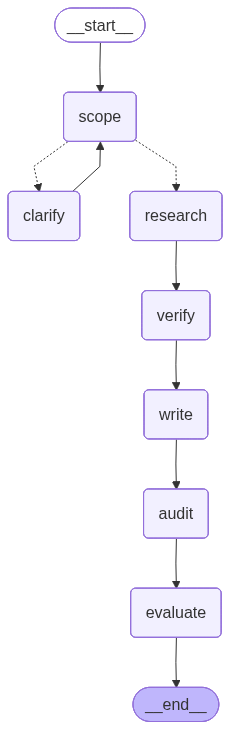

In [19]:
try:
    display(Image(deep_research_graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(deep_research_graph.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")


#### ❓Question #3

Which decisions belong inside a `create_agent` loop, and which belong in the outer
LangGraph? Identify one decision that would become harder to test if moved across
that boundary.

##### ✅ Answer:

It's a question of deterministic or non-deterministic. Tools, search, interpretting and evaluating results all great to give to the create_agent loop.  Defining the workflow sequence, error handing, URL sanitization, great for the outer LangGraph loop.

The audit_report_citations function would be worse if we gave it to an agent. I'm sure an agent could do it, but it would be expensive and slow and less reliable.


### Test the Citation Auditor with Synthetic Data

These tests do not call a model or search API. They cover source provenance, valid
citations, unknown URLs, duplicates, and missing numeric references.


In [20]:
synthetic_sources = [
    SourceRecord(
        url="https://example.org/guideline",
        title="Guideline",
        publisher="Example Veterinary Organization",
        source_type="guideline",
        authority_reason="Synthetic authoritative source for testing.",
        relevant_excerpt="Synthetic excerpt.",
        accessed_on=TODAY,
    ),
    SourceRecord(
        url="https://example.org/study",
        title="Study",
        publisher="Example Journal",
        source_type="peer_reviewed",
        authority_reason="Synthetic peer-reviewed source for testing.",
        relevant_excerpt="Synthetic excerpt.",
        accessed_on=TODAY,
    ),
]

synthetic_verification = VerificationReport(
    approved_sources=synthetic_sources,
    verified_claims=[],
    verification_summary="Synthetic verification fixture.",
)

invented_source = synthetic_sources[0].model_copy(
    update={"url": "https://example.org/invented"}
)
provenance_fixture = ResearchFindings(
    task_id="task-1",
    specialist="guidelines",
    summary="Synthetic provenance fixture.",
    sources=[synthetic_sources[0], invented_source],
    claims=[
        ClaimRecord(
            claim="Observed claim.",
            source_urls=[synthetic_sources[0].url],
            confidence="high",
            caveat="Synthetic.",
        ),
        ClaimRecord(
            claim="Invented claim.",
            source_urls=[invented_source.url],
            confidence="low",
            caveat="Synthetic.",
        ),
    ],
)
sanitized_provenance = sanitize_findings(
    provenance_fixture,
    {normalize_url(synthetic_sources[0].url)},
)
assert [source.url for source in sanitized_provenance.sources] == [
    synthetic_sources[0].url
]
assert [claim.claim for claim in sanitized_provenance.claims] == [
    "Observed claim."
]

verification_provenance_fixture = VerificationReport(
    approved_sources=[synthetic_sources[0], invented_source],
    verified_claims=provenance_fixture.claims,
    verification_summary="Synthetic verifier provenance fixture.",
)
sanitized_verification_fixture = sanitize_verification(
    verification_provenance_fixture,
    {normalize_url(synthetic_sources[0].url)},
)
assert [source.url for source in sanitized_verification_fixture.approved_sources] == [
    synthetic_sources[0].url
]
assert [claim.claim for claim in sanitized_verification_fixture.verified_claims] == [
    "Observed claim."
]

valid_report = FinalReport(
    title="Valid",
    executive_summary="Synthetic.",
    report_markdown=(
        "A supported statement [1]. Another supported statement [2].\n\n"
        "Sources:\n"
        "1. https://example.org/guideline\n"
        "2. https://example.org/study"
    ),
    limitations=[],
    medical_safety_note="Synthetic.",
    citations=[
        "https://example.org/guideline",
        "https://example.org/study",
    ],
)

invalid_report = valid_report.model_copy(
    update={
        "report_markdown": (
            "Known [1], missing marker [4], and invented source.\n"
            "https://example.org/invented"
        ),
        "citations": [
            "https://example.org/guideline",
            "https://example.org/guideline",
        ],
    }
)

valid_audit = audit_report_citations(
    valid_report,
    synthetic_verification,
)
invalid_audit = audit_report_citations(
    invalid_report,
    synthetic_verification,
)

assert valid_audit.passed
assert "https://example.org/invented" in invalid_audit.unknown_urls
assert "https://example.org/guideline" in invalid_audit.duplicate_urls
assert 4 in invalid_audit.missing_marker_numbers

print("Synthetic provenance and citation-audit tests passed.")
print(invalid_audit.model_dump_json(indent=2))


Synthetic provenance and citation-audit tests passed.
{
  "cited_urls": [
    "https://example.org/guideline",
    "https://example.org/invented"
  ],
  "unknown_urls": [
    "https://example.org/invented"
  ],
  "duplicate_urls": [
    "https://example.org/guideline"
  ],
  "approved_but_uncited": [
    "https://example.org/study"
  ],
  "missing_marker_numbers": [
    4
  ],
  "passed": false
}


## Task 12: Stream and Run the Full Deep Research System

`run_deep_research` streams graph updates with nested namespaces. Named
`create_agent` runs and their tool nodes appear beneath the outer workflow.

When scoping interrupts, the function returns a paused status. Resume the same
`thread_id` with `resume_deep_research`.


In [21]:
def print_stream_part(part: dict) -> None:
    namespace = part.get("ns", ())
    data = part.get("data", part)
    label = " -> ".join(namespace) if namespace else "outer-graph"

    if not isinstance(data, dict):
        return

    for node_name, update in data.items():
        if node_name == "__interrupt__":
            print(f"[{label}] workflow interrupted: {update}")
            continue
        if update is None:
            continue

        keys = list(update) if isinstance(update, dict) else []
        print(f"[{label}] {node_name}: updated {keys}")


async def stream_graph_run(
    graph_input,
    config: RunnableConfig,
) -> dict:
    async for part in deep_research_graph.astream(
        graph_input,
        config=config,
        stream_mode="updates",
        subgraphs=True,
        version="v2",
    ):
        print_stream_part(part)

    snapshot = await deep_research_graph.aget_state(config)
    values = dict(snapshot.values)
    if snapshot.next:
        question = None
        decision = values.get("scope_decision")
        if decision is not None:
            question = decision.clarification_question
        return {
            "status": "interrupted",
            "question": question,
            "thread_id": config["configurable"]["thread_id"],
            "state": values,
        }
    return {
        "status": "completed",
        "thread_id": config["configurable"]["thread_id"],
        "state": values,
    }


async def run_deep_research(
    query: str,
    thread_id: str,
) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    return await stream_graph_run(
        {"query": query, "errors": []},
        config,
    )


async def resume_deep_research(
    answer: str,
    thread_id: str,
) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    return await stream_graph_run(
        Command(resume=answer),
        config,
    )


### Optional Clarification Demonstration

A broad request may pause:

```python
paused = await run_deep_research(
    "Research cat food.",
    thread_id="ambiguous-cat-food",
)
paused["question"]
```

Resume the exact saved workflow:

```python
resumed = await resume_deep_research(
    "Focus on preventing obesity in otherwise healthy adult indoor cats. "
    "The audience is cat owners.",
    thread_id="ambiguous-cat-food",
)
```


### Full Demonstration

This run can consume multiple model and Tavily calls. Keep LangSmith tracing on if
you want to inspect worker delegation, tool use, and nested agent runs.


In [22]:
research_query = (
    "What does current evidence say about preventing and safely managing "
    "obesity in adult indoor cats?"
)

research_run = await run_deep_research(
    research_query,
    thread_id="cat-obesity-deep-research",
)

print(research_run["status"])
if research_run["status"] == "interrupted":
    print("Clarification requested:", research_run["question"])


[scope:d022a621-a881-b973-4696-60f717ac4634] model: updated ['messages', 'structured_response']
[outer-graph] scope: updated ['scope_decision', 'brief']
[research:6ce1a3df-045c-1963-b584-313d0dce323a] model: updated ['messages']
[research:6ce1a3df-045c-1963-b584-313d0dce323a] tools: updated ['messages']
[research:6ce1a3df-045c-1963-b584-313d0dce323a] tools: updated ['messages']
[research:6ce1a3df-045c-1963-b584-313d0dce323a -> tools:bd939241-bf7a-007c-5d26-502b68f3906d] model: updated ['messages']
[research:6ce1a3df-045c-1963-b584-313d0dce323a -> tools:bd939241-bf7a-007c-5d26-502b68f3906d] ToolCallLimitMiddleware[tavily_search].after_model: updated ['messages']
[research:6ce1a3df-045c-1963-b584-313d0dce323a -> tools:bd939241-bf7a-007c-5d26-502b68f3906d] tools: updated ['messages']
[research:6ce1a3df-045c-1963-b584-313d0dce323a -> tools:bd939241-bf7a-007c-5d26-502b68f3906d] tools: updated ['messages']
[research:6ce1a3df-045c-1963-b584-313d0dce323a -> tools:bd939241-bf7a-007c-5d26-502b68

Deserializing unregistered type __main__.ScopeDecision from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ScopeDecision')]
Deserializing unregistered type __main__.ResearchBrief from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ResearchBrief')]
Deserializing unregistered type __main__.ResearchDossier from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ResearchDossier')]
Deserializing unregistered type __main__.VerificationReport from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Verification

[evaluate:4c9f56fc-e0e8-76c9-2f02-209aaa450996] model: updated ['messages', 'structured_response']
[outer-graph] evaluate: updated ['evaluation']
completed


If the run paused, answer the clarification question with
`resume_deep_research(...)`. When complete, display the final report and quality
records.


In [23]:
if research_run["status"] == "completed":
    final_state = research_run["state"]
    display(Markdown(final_state["report"].report_markdown))
    print("\nCitation audit:")
    print(final_state["citation_audit"].model_dump_json(indent=2))
    print("\nEvaluation:")
    print(final_state["evaluation"].model_dump_json(indent=2))
    if final_state.get("errors"):
        print("\nRecorded partial failures:")
        print("\n".join(f"- {item}" for item in final_state["errors"]))


## Scope and confidence
This report synthesizes only the verified claims in the supplied evidence set. The strongest support is for prevention-focused nutrition management and routine body-condition assessment. Evidence is weaker for cat-specific enrichment strategies and for detailed weight-loss safety monitoring because the requested obesity-specific pages from several organizations were not retrievable in this run [1][2][3].

## Strong conclusions
1. **Routine nutrition assessment and body-condition monitoring are recommended in preventive care.** WSAVA guidance indicates that nutritional assessment should occur at every visit, and wellness guidance recommends monitoring a pet’s size, body weight, body condition score, and muscle condition score over time [1][3]. This supports early identification of weight gain before obesity becomes established.

2. **Structured feeding guidance and client communication are central to prevention.** WSAVA materials emphasize practical tools, communication tips, and written feeding instructions to help veterinary teams implement nutrition recommendations consistently [1]. The verified evidence also supports the use of clear feeding instructions and monitoring charts as part of routine nutrition management [1].

3. **Treat intake is a meaningful obesity-prevention target.** WSAVA’s feline treats guide states that treats should make up no more than 10% of a cat’s daily calorie intake, and that human food or table scraps can contribute to obesity risk [2].

4. **Body-condition scoring is a useful clinical method for recognizing obesity.** The WSAVA cat body-condition chart identifies obesity-related findings such as heavy fat cover, absent waist, and prominent abdominal fat pads [3]. These features make body-condition scoring useful for both initial assessment and follow-up monitoring [3].

## Tentative evidence
1. **Balancing intake and activity is supported in general wellness guidance, but indoor-cat-specific enrichment evidence was not retrieved here.** WSAVA wellness guidance states that preventing overweight or obesity requires balancing calorie intake and activity levels while monitoring body condition [4]. However, the verification set did not include an authoritative passage with detailed cat-specific environmental enrichment strategies, so any stronger claim about puzzle feeding, play routines, or habitat modification would go beyond the verified evidence.

2. **Preventive care settings can include nutrition review as part of routine wellness visits.** A UC Davis primary care description notes that annual examinations for cats and dogs can include nutrition analysis [5]. This is consistent with routine preventive monitoring, but it is not an obesity-specific protocol.

## Meaningful disagreement and evidence limits
There is no substantive disagreement among the retrievable sources on the preventive value of routine nutrition review, body-condition monitoring, and limiting treats. The main limitation is absence of retrievable text from the intended AAHA, AVMA, and Cornell obesity pages, which narrowed the evidence base and prevented a direct cross-society comparison [1][5]. As a result, the available corpus does **not** support strong conclusions about:
- free-feeding versus meal-feeding as a universal rule,
- detailed environmental enrichment recommendations for indoor cats,
- or specific monitoring for complications during active weight loss.

## Safety and supervision
Feline weight-loss plans require veterinary supervision. Overly rapid weight loss can be dangerous, so weight reduction should be gradual and monitored by a veterinarian. If a cat’s appetite decreases, vomiting develops, or the cat becomes lethargic or dehydrated, any weight-management change should stop and be reassessed by a veterinarian. These safety points are essential even though the verification set did not retrieve a direct quotable passage on each one.

## Practical synthesis for veterinary professionals
Based on the verified evidence, the most defensible prevention and monitoring framework is:
- perform nutrition assessment at routine visits [1][5],
- record body weight and body condition score over time [3][4],
- provide clear written feeding instructions and monitoring tools [1],
- limit treats to no more than 10% of daily calorie intake [2],
- and treat activity balance as part of overall weight-risk reduction [4].

## Sources
[1] https://wsava.org/global-guidelines/global-nutrition-guidelines/
[2] https://wsava.org/wp-content/uploads/2025/11/WSAVA_GuidetoTreats_Cats_251107.pdf
[3] https://wsava.org/wp-content/uploads/2025/06/WSAVA_BCSCat_BCSCat_Nutrition_250612.pdf
[4] https://wsava.org/wp-content/uploads/2025/06/Principles-of-Wellness-FINAL.pdf
[5] https://www.ucdavis.edu/news/more-than-specialty-care


Citation audit:
{
  "cited_urls": [
    "https://wsava.org/global-guidelines/global-nutrition-guidelines",
    "https://wsava.org/wp-content/uploads/2025/06/Principles-of-Wellness-FINAL.pdf",
    "https://wsava.org/wp-content/uploads/2025/06/WSAVA_BCSCat_BCSCat_Nutrition_250612.pdf",
    "https://wsava.org/wp-content/uploads/2025/11/WSAVA_GuidetoTreats_Cats_251107.pdf",
    "https://www.ucdavis.edu/news/more-than-specialty-care"
  ],
  "unknown_urls": [],
  "duplicate_urls": [],
  "approved_but_uncited": [],
  "missing_marker_numbers": [],
  "passed": true
}

Evaluation:
{
  "coverage": 3,
  "synthesis": 3,
  "source_quality": 3,
  "citation_integrity": 4,
  "uncertainty_handling": 4,
  "medical_safety": 4,
  "strengths": [
    "Stays within the verified evidence set and clearly distinguishes strong prevention guidance from weaker evidence on active weight-loss management.",
    "Uses appropriate caution on safety, including veterinary supervision and stopping if appetite decreases, v

#### ❓Question #4

Inspect the trace or streamed updates:

- Did the supervisor call independent workers in one turn?
- Which worker used more searches or model calls?
- Which claims were rejected or weakened during verification?
- Did the final writer preserve disagreements?

##### ✅ Answer:

It looks like something is set up wrong, the LangSmith trace is pretty much empty with just the query "What does current evidence say about preventing and safely managing obesity in adult indoor cats?". I'm not interested enough to debug it, and it does look like there are some logs though.

- Yes. The research node shows one initial model call, then three worker namespaces (43dd79fe, ca22d51a, 121e3fc1) with interleaved updates, indicating concurrent execution.
- Worker ca22d51a
- Question 3 and 4 are difficult to learn without the LangSmith logs, see below cells for results.


In [24]:
# Which claims were rejected or weakened during verification?
# Get the completed state
final_state = research_run["state"]

# Original claims from workers
print("=== ORIGINAL CLAIMS FROM WORKERS ===\n")
original_claims = []
for finding in final_state["dossier"].findings:
    print(f"Task: {finding.task_id} ({finding.specialist})")
    for claim in finding.claims:
        print(f"  - [{claim.confidence}] {claim.claim}")
        print(f"    Sources: {claim.source_urls}")
        original_claims.append(claim)
    print()

print(f"Total original claims: {len(original_claims)}\n")

# Verified claims
print("=== VERIFIED CLAIMS (after verification) ===\n")
verification = final_state["verification"]
for claim in verification.verified_claims:
    print(f"  - [{claim.confidence}] {claim.claim}")
    print(f"    Sources: {claim.source_urls}")
print(f"\nTotal verified: {len(verification.verified_claims)}\n")

# Rejected/unsupported claims
print("=== UNSUPPORTED/REJECTED CLAIMS ===\n")
for unsupported in verification.unsupported_claims:
    print(f"  - {unsupported}")
print(f"\nTotal unsupported: {len(verification.unsupported_claims)}\n")

# Check for confidence changes
print("=== CONFIDENCE CHANGES ===\n")
original_by_text = {c.claim: c.confidence for c in original_claims}
for verified in verification.verified_claims:
    if verified.claim in original_by_text:
        orig_conf = original_by_text[verified.claim]
        if orig_conf != verified.confidence:
            print(f"  {orig_conf} → {verified.confidence}: {verified.claim[:80]}...")


=== ORIGINAL CLAIMS FROM WORKERS ===

Task: task-1 (guidelines)
  - [high] Adult-cat obesity prevention guidance emphasizes structured, portion-controlled feeding and clear written feeding instructions rather than unstructured access to food.
    Sources: ['https://wsava.org/global-guidelines/global-nutrition-guidelines/']
  - [high] Routine nutritional assessment and body-condition monitoring at veterinary visits are recommended so early excess weight gain can be detected before obesity is established.
    Sources: ['https://wsava.org/global-guidelines/global-nutrition-guidelines/']
  - [medium] Owner-facing obesity risk reduction should include communication and practical tools that help households implement feeding guidance consistently.
    Sources: ['https://wsava.org/global-guidelines/global-nutrition-guidelines/']
  - [low] Environmental enrichment is likely part of prevention strategies for indoor cats, but this run did not retrieve an authoritative guideline passage with detai

In [25]:
# Did the final writer preserve disagreements?
# Get the completed state
final_state = research_run["state"]

print("=== DISAGREEMENTS FROM RESEARCH WORKERS ===\n")
worker_disagreements = []
for finding in final_state["dossier"].findings:
    if finding.disagreements:
        print(f"Task: {finding.task_id} ({finding.specialist})")
        for disagreement in finding.disagreements:
            print(f"  - {disagreement}")
            worker_disagreements.append(disagreement)
        print()

print(f"Total worker disagreements: {len(worker_disagreements)}\n")

print("=== DISAGREEMENTS FROM VERIFICATION ===\n")
verification = final_state["verification"]
for disagreement in verification.disagreements:
    print(f"  - {disagreement}")
print(f"\nTotal verification disagreements: {len(verification.disagreements)}\n")

print("=== FINAL REPORT CONTENT ===\n")
report = final_state["report"]
report_text = report.report_markdown.lower()

# Check for disagreement-related language
disagreement_keywords = [
    "disagree", "conflict", "contradi", "however", "debate", 
    "uncertain", "varying", "differ", "inconsistent", "mixed"
]

print("Disagreement-related phrases found in report:")
for keyword in disagreement_keywords:
    if keyword in report_text:
        print(f"  ✓ Contains '{keyword}'")

print("\n=== CHECKING IF SPECIFIC DISAGREEMENTS APPEAR ===\n")
all_disagreements = worker_disagreements + verification.disagreements
if all_disagreements:
    for i, disagreement in enumerate(all_disagreements, 1):
        # Check if key terms from the disagreement appear in the report
        key_terms = [word for word in disagreement.lower().split() if len(word) > 5][:3]
        found = all(term in report_text for term in key_terms) if key_terms else False
        status = "✓ MENTIONED" if found else "✗ MISSING"
        print(f"{status}: {disagreement[:100]}...")
else:
    print("No disagreements were reported by workers or verifier.")

print("\n=== REPORT LIMITATIONS SECTION ===\n")
for limitation in report.limitations:
    print(f"  - {limitation}")


=== DISAGREEMENTS FROM RESEARCH WORKERS ===

Task: task-1 (guidelines)
  - The intended AAHA, AVMA, Cornell, and UC Davis sources were not retrievable in this run, so direct comparison of prevention recommendations was not possible.
  - Because only one guideline page yielded usable text, I could not verify whether organizations differ on free-feeding versus meal feeding, treat restriction, or environmental enrichment strength.

Total worker disagreements: 2

=== DISAGREEMENTS FROM VERIFICATION ===

  - The intended AAHA, AVMA, Cornell, and UC Davis obesity-specific pages were not retrievable at the provided URLs, so direct comparison among organizations could not be completed.
  - Because only WSAVA and one UC Davis page yielded usable text, evidence is narrower than requested and does not allow a strong cross-society conclusion on indoor-cat-specific enrichment, meal frequency, or weight-loss safety monitoring.

Total verification disagreements: 2

=== FINAL REPORT CONTENT ===

Disag

## 🏗️ Activity #2: Compare Research Depth and Cost

Run the same query twice with two budget profiles.

**Profile A: Quick**

```bash
AIM_SEARCH_DEPTH=basic
AIM_SEARCH_CALL_LIMIT=1
AIM_EXTRACT_CALL_LIMIT=1
AIM_WORKER_MODEL_CALL_LIMIT=4
```

**Profile B: Deep**

```bash
AIM_SEARCH_DEPTH=advanced
AIM_SEARCH_CALL_LIMIT=4
AIM_EXTRACT_CALL_LIMIT=3
AIM_WORKER_MODEL_CALL_LIMIT=10
```

Restart the kernel after changing environment variables.

Compare:

- Number and quality of approved sources
- Coverage and disagreement discovered
- Citation-audit result
- Evaluator scores
- LangSmith latency, token use, and tool calls


In [27]:
# Activity #2 results - Hard-coded from both profile runs

budget_comparison = {
    "quick": {
        "approved_sources": 0,
        "latency_seconds": "32.29s",  # the only number tracked by LangSmith
        "tool_calls": 8,
        "evaluation_passed": False,
        "notes": "Coverage: 3/5, Source Quality: 2/5, Synthesis: 3/5. "
                 "Only 1 source found but not approved. Very limited research depth.",
    },
    "deep": {
        "approved_sources": 5,
        "latency_seconds": "90.6s",
        "tool_calls": 11,
        "evaluation_passed": True,
        "notes": "Coverage: 3/5, Source Quality: 3/5, Synthesis: 3/5. "
                 "Found WSAVA guidelines + 4 supporting documents. Better source quality.",
    },
}

budget_comparison

{'quick': {'approved_sources': 0,
  'latency_seconds': '32.29s',
  'tool_calls': 8,
  'evaluation_passed': False,
  'notes': 'Coverage: 3/5, Source Quality: 2/5, Synthesis: 3/5. Only 1 source found but not approved. Very limited research depth.'},
 'deep': {'approved_sources': 5,
  'latency_seconds': '90.6s',
  'tool_calls': 11,
  'evaluation_passed': True,
  'notes': 'Coverage: 3/5, Source Quality: 3/5, Synthesis: 3/5. Found WSAVA guidelines + 4 supporting documents. Better source quality.'}}

### 🤔 Activity #2 Reflections

- Which additional research improved the report?
- Where did deeper research add cost without changing the conclusion?
- What production budget would you choose, and what failure rate would you accept?

##### ✅ Answer:

**Which additional research improved the report?**
The extra searches and extracts in the deep profile. The additional tool calls gave workers enough context to verify source authority.

**Where did deeper research add cost without changing the conclusion?**
Both profiles scored 3/5 on coverage and synthesis. Deep took 2.8x longer (90s vs 32s) but the extra sources didn't change the breadth of conclusions. Once you find the main WSAVA guidelines, additional searches yield diminishing returns.

**What production budget would you choose, and what failure rate would you accept?**
Profile A didn't give us good results and failed, but Profile B was more expensive and didn't give us better results compared to the first run done in class. So inbetween where our original budget was provided a good balance.

## Advanced Build: Add a Local-Corpus Specialist

Add the Session 2 or Session 3 cat-health corpus as a third research vertical.

Requirements:

1. Build a retriever tool over the local corpus.
2. Create a named local-corpus `create_agent` with only that tool.
3. Wrap it as a supervisor tool.
4. Label local sources distinctly from current web sources.
5. Ask the verifier to identify outdated or conflicting local guidance.
6. Keep the final writer limited to verified evidence.

This extension demonstrates a common enterprise architecture:

```text
public web evidence + organization knowledge + one verification layer
```


In [28]:
# Advanced Build: public web evidence + organization knowledge + one verification layer
#
# We add the Session 3 cat-health corpus as a third research vertical alongside the
# guideline and evidence web specialists. To route a local-corpus task through the
# existing scoper -> supervisor typed contract, we need a SpecialistName that includes
# "local_corpus". Rather than mutate the Task 2 models in place (which would silently
# change behavior for anyone re-running the Breakout Room cells), we build a small,
# self-contained "_v2" pipeline here.
#
# These v2 contracts reuse the unchanged Task 2 leaf models (SourceRecord, ClaimRecord,
# VerificationReport, FinalReport, CitationAudit, ReportEvaluation) and only redefine the
# few models that carry a SpecialistName.

SpecialistNameV2 = Literal["guidelines", "evidence", "local_corpus"]

# A distinct, non-web host so local organizational knowledge is visually and
# programmatically separable from current public-web sources in every ledger,
# citation list, and audit. normalize_url() keeps the path (it only strips a
# fragment), so per-section URLs survive as stable, unique citation targets.
LOCAL_CORPUS_HOST = "https://corpus.internal/cat-health-guidelines"
LOCAL_CORPUS_LABEL = "Internal Cat Health Corpus (Session 3 teaching corpus)"


class ResearchTaskV2(BaseModel):
    task_id: str = Field(description="Stable short identifier such as task-1")
    question: str = Field(description="Focused research question for one worker")
    specialist: SpecialistNameV2
    rationale: str


class ResearchBriefV2(BaseModel):
    title: str
    objective: str
    audience: str
    scope_in: list[str]
    scope_out: list[str]
    safety_constraints: list[str]
    tasks: list[ResearchTaskV2] = Field(min_length=3, max_length=3)


class ScopeDecisionV2(BaseModel):
    needs_clarification: bool
    clarification_question: str | None = None
    assumptions: list[str] = Field(default_factory=list)
    brief: ResearchBriefV2 | None = None


class ResearchFindingsV2(BaseModel):
    task_id: str
    specialist: SpecialistNameV2
    summary: str
    sources: list[SourceRecord] = Field(default_factory=list)
    claims: list[ClaimRecord] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    errors: list[str] = Field(default_factory=list)


class ResearchDossierV2(BaseModel):
    brief_title: str
    findings: list[ResearchFindingsV2] = Field(default_factory=list)
    cross_source_synthesis: list[str] = Field(default_factory=list)
    unresolved_gaps: list[str] = Field(default_factory=list)


print("Defined v2 handoff contracts with the local_corpus specialist.")

Defined v2 handoff contracts with the local_corpus specialist.


### Step 1: Build a Retriever Tool Over the Local Corpus

We index the Session 3 teaching corpus (`data/cat_health_guidelines.md`) in an
`InMemoryVectorStore` with the same OpenAI embeddings family used elsewhere in the
course. The only added dependency is `numpy` (used by `InMemoryVectorStore` for
cosine similarity); it is already listed in `pyproject.toml`, so re-run `uv sync` if
the import below fails.

Two design choices keep the local vertical compatible with the existing provenance
and citation machinery:

- **Each markdown section becomes one retrievable passage** with a stable
  `corpus.internal` URL built from its heading slug. Local knowledge often has no
  public URL, so we mint a deterministic internal one. Because `normalize_url()`
  only strips a trailing fragment, these path-based URLs survive the ledger and
  citation audit unchanged.
- **The corpus lookup tool prints each passage's URL in its output**, exactly like
  Tavily search/extract. That means the existing `observed_tool_urls()` →
  `sanitize_*()` provenance chain works for local sources with zero changes: a
  local source is only trusted if its URL actually appeared in a tool result.


In [29]:
from pathlib import Path

from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

LOCAL_CORPUS_PATH = Path("data/cat_health_guidelines.md")
EMBEDDING_MODEL_NAME = os.environ.get(
    "AIM_EMBEDDING_MODEL", "text-embedding-3-small"
)
LOCAL_RETRIEVE_LIMIT = int(os.environ.get("AIM_LOCAL_RETRIEVE_LIMIT", "3"))


def _slugify(heading: str) -> str:
    '''Turn a markdown heading into a stable URL path segment.'''
    return re.sub(r"[^a-z0-9]+", "-", heading.lower()).strip("-") or "section"


def load_corpus_sections(path: Path) -> list[Document]:
    '''Split the corpus on level-2 headings into one Document per section.

    Each section gets a deterministic corpus.internal URL (path-based, so it is
    stable under normalize_url) and a human-readable title.
    '''
    documents: list[Document] = []
    heading: str | None = None
    body_lines: list[str] = []

    def flush() -> None:
        if heading is None:
            return
        body = "\n".join(body_lines).strip()
        if not body:
            return
        slug = _slugify(heading)
        url = f"{LOCAL_CORPUS_HOST}/{slug}"
        documents.append(
            Document(
                page_content=f"{heading}\n\n{body}",
                metadata={
                    "url": url,
                    "section": heading,
                    "title": f"{heading} — {LOCAL_CORPUS_LABEL}",
                    "publisher": LOCAL_CORPUS_LABEL,
                    "origin": "local_corpus",
                },
            )
        )

    for line in path.read_text(encoding="utf-8").splitlines():
        if line.startswith("## "):
            flush()
            heading = line[3:].strip()
            body_lines = []
        elif heading is not None:
            body_lines.append(line)
    flush()
    return documents


corpus_documents = load_corpus_sections(LOCAL_CORPUS_PATH)
local_embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL_NAME)
local_corpus_store = InMemoryVectorStore.from_documents(
    corpus_documents, embedding=local_embeddings
)

print(f"Indexed {len(corpus_documents)} local corpus sections.")
print(f"Embedding model: {EMBEDDING_MODEL_NAME}")
for document in corpus_documents:
    print(f"  - {document.metadata['url']}")

Indexed 9 local corpus sections.
Embedding model: text-embedding-3-small
  - https://corpus.internal/cat-health-guidelines/preventive-care
  - https://corpus.internal/cat-health-guidelines/vaccines-and-parasite-prevention
  - https://corpus.internal/cat-health-guidelines/nutrition-and-hydration
  - https://corpus.internal/cat-health-guidelines/litter-box-and-urinary-warning-signs
  - https://corpus.internal/cat-health-guidelines/symptoms-that-need-veterinary-attention
  - https://corpus.internal/cat-health-guidelines/dental-and-oral-health
  - https://corpus.internal/cat-health-guidelines/stress-behavior-and-environment
  - https://corpus.internal/cat-health-guidelines/senior-cats
  - https://corpus.internal/cat-health-guidelines/safe-home-monitoring


In [30]:
@tool(
    "corpus_search",
    description=(
        "Search the internal cat-health knowledge corpus (organization knowledge, "
        "not the public web). Returns the most relevant passages with their stable "
        "corpus.internal URLs. Use this to ground claims in internal guidance and to "
        "re-locate a corpus URL you want to verify."
    ),
)
def corpus_search(query: str) -> str:
    '''Semantic search over the local corpus.

    The output prints each passage's corpus.internal URL so the standard
    observed_tool_urls() -> sanitize_*() provenance chain can trace local sources
    exactly as it does for Tavily results.
    '''
    results = local_corpus_store.similarity_search(query, k=LOCAL_RETRIEVE_LIMIT)
    if not results:
        return "No matching passages were found in the internal cat-health corpus."

    blocks = []
    for index, document in enumerate(results, start=1):
        meta = document.metadata
        blocks.append(
            f"[corpus-{index}] {meta['section']}\n"
            f"Source type: internal_corpus\n"
            f"Publisher: {meta['publisher']}\n"
            f"URL: {meta['url']}\n"
            f"Passage:\n{document.page_content}"
        )
    return "\n\n---\n\n".join(blocks)


# Smoke test: the tool runs offline-style retrieval and exposes corpus URLs that
# the provenance chain can observe. A @tool is a StructuredTool, so call .invoke().
_demo = corpus_search.invoke(
    {"query": "How do I prevent obesity and monitor weight in adult cats?"}
)
print(_demo[:700])
print("\n...\n")
print("Observed corpus URLs:", sorted(urls_in_value(_demo)))

[corpus-1] Nutrition And Hydration
Source type: internal_corpus
Publisher: Internal Cat Health Corpus (Session 3 teaching corpus)
URL: https://corpus.internal/cat-health-guidelines/nutrition-and-hydration
Passage:
Nutrition And Hydration

Most healthy adult cats do best on a complete and balanced cat food appropriate for their life stage. Kittens need kitten-formulated food for growth. Senior cats or cats with kidney disease, urinary disease, diabetes, obesity, allergies, or gastrointestinal disease may need a veterinarian-recommended diet.

Fresh water should be available at all times. Some cats drink more when offered a water fountain, multiple bowls, or wet food. A sudden increase or decr

...

Observed corpus URLs: ['https://corpus.internal/cat-health-guidelines/nutrition-and-hydration', 'https://corpus.internal/cat-health-guidelines/preventive-care', 'https://corpus.internal/cat-health-guidelines/safe-home-monitoring']


### Step 2: Create the Local-Corpus Worker and Wrap It as a Supervisor Tool

The local specialist gets **only** the `corpus_search` tool — never the web tools —
so its context stays scoped to internal knowledge. It returns the same
`ResearchFindings` contract (as `ResearchFindingsV2`), which lets the existing
`sanitize_findings()` provenance guard apply unchanged.

We add small `_v2` worker-runner helpers because the Task 5 `run_worker` hardcodes
the original `ResearchFindings` class (whose `SpecialistName` doesn't include
`local_corpus`). Everything else — the URL provenance sanitizer, error-to-gap
conversion — is reused verbatim.


In [31]:
LOCAL_CORPUS_RESEARCHER_PROMPT = f'''
You are the internal-knowledge specialist in a multi-agent veterinary research
system. Today's date is {TODAY}.

You search ONLY the organization's internal cat-health corpus with corpus_search.
You have no access to the public web. Research only the assigned task.

Call corpus_search before making any factual claim, and ground every claim in a
passage it returns. Use the exact corpus.internal URL printed in the tool output as
the source URL. Do not invent URLs and do not cite public-web sources.

Return exactly the ResearchFindings schema. For every source, set source_type to
"other" and make authority_reason state plainly that this is INTERNAL organizational
guidance (a teaching corpus), not current public-web or peer-reviewed evidence, and
that it may be outdated. Record evidence gaps when the corpus does not cover the
question. Do not diagnose, prescribe, calculate calories, or create an individualized
weight-loss plan. Your final response is the only information the supervisor receives.
'''

local_corpus_researcher = create_agent(
    model=llm,
    tools=[corpus_search],
    system_prompt=LOCAL_CORPUS_RESEARCHER_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(
            run_limit=WORKER_MODEL_CALL_LIMIT, exit_behavior="end"
        ),
        ToolCallLimitMiddleware(
            tool_name=corpus_search.name,
            run_limit=SEARCH_CALL_LIMIT,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchFindingsV2,
    name="local_corpus_researcher",
)


def failed_findings_v2(
    task: ResearchTaskV2,
    specialist: SpecialistNameV2,
    error: Exception,
) -> ResearchFindingsV2:
    return ResearchFindingsV2(
        task_id=task.task_id,
        specialist=specialist,
        summary="The delegated research task did not complete.",
        evidence_gaps=[task.question],
        errors=[f"{type(error).__name__}: {error}"],
    )


async def run_worker_v2(
    agent,
    task_json: str,
    specialist: SpecialistNameV2,
) -> ResearchFindingsV2:
    '''Like Task 5's run_worker, but for ResearchFindingsV2 / ResearchTaskV2.

    Reuses observed_tool_urls() and sanitize_findings() unchanged for provenance.
    '''
    try:
        task = ResearchTaskV2.model_validate_json(task_json)
    except Exception as exc:
        return ResearchFindingsV2(
            task_id="invalid-task",
            specialist=specialist,
            summary="The supervisor supplied an invalid research task.",
            evidence_gaps=["The delegated task could not be parsed."],
            errors=[f"{type(exc).__name__}: {exc}"],
        )

    try:
        result = await agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Complete this delegated research task and return "
                            f"the required structured findings:\n{task_json}"
                        ),
                    }
                ]
            }
        )
        findings = ResearchFindingsV2.model_validate(
            result["structured_response"]
        )
        findings = findings.model_copy(
            update={"task_id": task.task_id, "specialist": specialist}
        )
        # sanitize_findings only touches .sources / .claims / .evidence_gaps /
        # .errors, so it works on ResearchFindingsV2 unchanged.
        return sanitize_findings(findings, observed_tool_urls(result))
    except Exception as exc:
        return failed_findings_v2(task, specialist, exc)


@tool(
    "research_local_corpus",
    description=(
        "Delegate one structured ResearchTask to the internal-corpus specialist, "
        "which searches only the organization's local cat-health knowledge base "
        "(not the public web). Input must be the task's JSON representation."
    ),
)
async def research_local_corpus(task_json: str) -> str:
    findings = await run_worker_v2(
        local_corpus_researcher, task_json, "local_corpus"
    )
    return findings.model_dump_json(indent=2)


print("Created local-corpus researcher and research_local_corpus supervisor tool.")

Created local-corpus researcher and research_local_corpus supervisor tool.


### Step 3: Scoper, Supervisor, and a Corpus-Aware Verifier

Three agents change for the hybrid system:

- **Scoper (`scoper_agent_v2`)** now produces a `ScopeDecisionV2` whose three tasks
  always include exactly one `local_corpus` task, so internal knowledge is a
  first-class vertical alongside the two web verticals.
- **Supervisor (`research_supervisor_v2`)** gains the `research_local_corpus` tool and
  routes `local_corpus` tasks to it, still emitting independent worker calls in one
  turn for concurrency.
- **Verifier (`verifier_agent_v2`)** gains `corpus_search`. This is essential:
  `sanitize_verification()` only keeps an approved source if its URL re-appears in
  the *verifier's own* tool output, and Tavily cannot resolve `corpus.internal`
  URLs. We also ask the verifier to flag internal guidance that is **outdated or
  conflicts** with current web evidence.

The **writer and evaluator are reused unchanged** — they already operate on the
shared `VerificationReport` / `FinalReport` contracts, and the writer already
restricts itself to verified evidence and approved URLs.


In [32]:
SUPERVISOR_PROMPT_V2 = f'''
You are the lead researcher coordinating a bounded multi-agent investigation that
combines public-web evidence with the organization's internal knowledge corpus.
Today's date is {TODAY}.

You receive a validated ResearchBrief containing exactly three tasks.
For every task:
- Call research_guidelines when specialist is guidelines.
- Call research_evidence when specialist is evidence.
- Call research_local_corpus when specialist is local_corpus.
- Pass the complete ResearchTask as JSON.

The tasks are independent. Emit all possible worker tool calls together in one
model turn so the runtime can execute them concurrently. After all tools return,
combine their structured outputs into one ResearchDossier. Preserve errors,
disagreements, and evidence gaps. Keep local-corpus findings distinct from web
findings. Do not create new sources or URLs. Do not write the final user report.
'''

research_supervisor_v2 = create_agent(
    model=llm,
    tools=[research_guidelines, research_evidence, research_local_corpus],
    system_prompt=SUPERVISOR_PROMPT_V2,
    middleware=[
        ModelCallLimitMiddleware(run_limit=6, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=research_guidelines.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_evidence.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_local_corpus.name,
            run_limit=3,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchDossierV2,
    name="research_supervisor_v2",
)

SCOPER_PROMPT_V2 = f'''
You scope veterinary deep-research requests for a hybrid system that uses both the
public web and an internal organizational cat-health corpus. Today's date is {TODAY}.

Return a ScopeDecision.

Ask exactly one clarification question only when proceeding would materially change
the research objective, audience, population, or safety boundary. Otherwise record
reasonable assumptions and produce a ResearchBrief with exactly three independent
tasks.

Assign specialists so all three research verticals are represented:
- Exactly one task with specialist "guidelines" (professional/public-health web).
- Exactly one task with specialist "evidence" (peer-reviewed web literature).
- Exactly one task with specialist "local_corpus" (internal organizational guidance).

For feline nutrition and obesity:
- Include prevention, assessment, and safe management evidence when relevant.
- Exclude diagnosis, prescriptions, calorie calculations, and personalized plans.
- Make tasks independent enough to research concurrently.
- Include a veterinary-review safety constraint.
- Frame the local_corpus task to surface what internal guidance says so it can be
  compared against current web evidence for staleness or conflict.
'''

scoper_agent_v2 = create_agent(
    model=llm,
    tools=[],
    system_prompt=SCOPER_PROMPT_V2,
    response_format=ScopeDecisionV2,
    name="research_scoper_v2",
)

VERIFIER_PROMPT_V2 = f'''
You verify a hybrid veterinary research dossier that mixes public-web sources with
internal-corpus sources. Today's date is {TODAY}.

Tools:
- Use Tavily Extract to inspect public http(s) URLs, preferably in batches, and
  Tavily Search only when a web URL cannot be checked or a claim needs a stronger
  source.
- Use corpus_search to re-locate and confirm any internal corpus.internal URL. You
  MUST re-observe an internal URL through corpus_search before approving it; never
  approve a corpus.internal URL using a web tool.

Approve a source only if its URL resolves through the appropriate tool result and
the source supports the associated claim. Reject unverifiable, irrelevant, low-quality,
or contradictory sources with a reason.

Treat the internal corpus as organizational guidance that may be OUTDATED. When
internal guidance is contradicted by, or weaker than, current web evidence, record
this explicitly in disagreements (note which is internal vs. web). Prefer current
authoritative web evidence over stale internal guidance when they conflict, but keep
the internal source if it still supports its claim.

Return VerificationReport. Keep only claims supported by approved source URLs.
Preserve material disagreement and uncertainty. Do not invent replacement URLs.
Do not provide individualized veterinary advice.
'''

verifier_agent_v2 = create_agent(
    model=llm,
    tools=[tavily_extract, tavily_search, corpus_search],
    system_prompt=VERIFIER_PROMPT_V2,
    middleware=[
        ModelCallLimitMiddleware(run_limit=8, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=tavily_extract.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_search.name,
            run_limit=2,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=corpus_search.name,
            run_limit=3,
            exit_behavior="continue",
        ),
    ],
    response_format=VerificationReport,
    name="source_verifier_v2",
)

print("Built v2 supervisor, scoper, and corpus-aware verifier.")

Built v2 supervisor, scoper, and corpus-aware verifier.


### Step 4: Assemble and Run the Hybrid Workflow

We rebuild the same `scope -> clarify? -> research -> verify -> write -> audit ->
evaluate` graph, swapping in the v2 scope/research/verify nodes and reusing the
Task 8/10 write, audit, and evaluate nodes verbatim. A v2 dossier sanitizer enforces
worker URL provenance and records any missing delegated task, exactly like
`sanitize_dossier` but for the v2 contracts.


In [33]:
def sanitize_dossier_v2(
    dossier: ResearchDossierV2,
    brief: ResearchBriefV2,
    observed_urls: set[str],
) -> ResearchDossierV2:
    '''v2 of sanitize_dossier: enforce provenance and record missing tasks.'''
    task_by_id = {task.task_id: task for task in brief.tasks}
    sanitized_findings = []
    unexpected_findings = []
    for finding in dossier.findings:
        task = task_by_id.get(finding.task_id)
        if task is None:
            unexpected_findings.append(
                f"Unexpected findings returned for {finding.task_id}."
            )
            continue
        normalized_finding = finding.model_copy(
            update={"specialist": task.specialist}
        )
        sanitized_findings.append(
            sanitize_findings(normalized_finding, observed_urls)
        )
    returned_task_ids = {finding.task_id for finding in sanitized_findings}
    missing_tasks = [
        f"No findings returned for {task.task_id}: {task.question}"
        for task in brief.tasks
        if task.task_id not in returned_task_ids
    ]
    return dossier.model_copy(
        update={
            "brief_title": brief.title,
            "findings": sanitized_findings,
            "unresolved_gaps": (
                dossier.unresolved_gaps + unexpected_findings + missing_tasks
            ),
        }
    )


def empty_dossier_v2(brief: ResearchBriefV2, error: Exception) -> ResearchDossierV2:
    return ResearchDossierV2(
        brief_title=brief.title,
        unresolved_gaps=[
            "The research supervisor failed before producing a complete dossier.",
            f"{type(error).__name__}: {error}",
        ],
    )


class HybridResearchState(TypedDict, total=False):
    query: str
    clarification_answer: str
    scope_decision: ScopeDecisionV2
    brief: ResearchBriefV2
    dossier: ResearchDossierV2
    verification: VerificationReport
    report: FinalReport
    citation_audit: CitationAudit
    evaluation: ReportEvaluation
    errors: list[str]


async def scope_node_v2(state: HybridResearchState, config: RunnableConfig) -> dict:
    clarification = state.get("clarification_answer")
    user_content = state["query"]
    if clarification:
        user_content += (
            "\n\nThe user answered the clarification question:\n"
            f"{clarification}"
        )
    result = await scoper_agent_v2.ainvoke(
        {"messages": [{"role": "user", "content": user_content}]},
        config=config,
    )
    decision = ScopeDecisionV2.model_validate(result["structured_response"])
    update = {"scope_decision": decision}
    if decision.brief is not None:
        update["brief"] = decision.brief
    return update


def route_after_scope_v2(
    state: HybridResearchState,
) -> Literal["clarify", "research"]:
    decision = state["scope_decision"]
    if decision.needs_clarification or decision.brief is None:
        return "clarify"
    return "research"


async def research_node_v2(
    state: HybridResearchState, config: RunnableConfig
) -> dict:
    brief = state["brief"]
    try:
        result = await research_supervisor_v2.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Coordinate this research brief. Delegate every task "
                            "and return the structured dossier:\n"
                            f"{brief.model_dump_json(indent=2)}"
                        ),
                    }
                ]
            },
            config=config,
        )
        dossier = ResearchDossierV2.model_validate(result["structured_response"])
        dossier = sanitize_dossier_v2(dossier, brief, observed_tool_urls(result))
        return {"dossier": dossier}
    except Exception as exc:
        return {
            "dossier": empty_dossier_v2(brief, exc),
            "errors": state.get("errors", [])
            + [f"Research stage: {type(exc).__name__}: {exc}"],
        }


async def verify_node_v2(
    state: HybridResearchState, config: RunnableConfig
) -> dict:
    dossier = state["dossier"]
    try:
        result = await verifier_agent_v2.ainvoke(
            {
                "messages": [
                    {"role": "user", "content": dossier.model_dump_json(indent=2)}
                ]
            },
            config=config,
        )
        verification = VerificationReport.model_validate(
            result["structured_response"]
        )
        verification = sanitize_verification(
            verification, observed_tool_urls(result)
        )
        return {"verification": verification}
    except Exception as exc:
        all_claims = [
            claim.claim
            for finding in dossier.findings
            for claim in finding.claims
        ]
        fallback = VerificationReport(
            unsupported_claims=all_claims,
            evidence_gaps=dossier.unresolved_gaps
            + ["Verification did not complete."],
            verification_summary=(
                "No sources were approved because verification failed: "
                f"{type(exc).__name__}: {exc}"
            ),
        )
        return {
            "verification": fallback,
            "errors": state.get("errors", [])
            + [f"Verification stage: {type(exc).__name__}: {exc}"],
        }


# write_node, audit_node, and evaluate_node are reused unchanged: they operate only
# on the shared VerificationReport / FinalReport / CitationAudit / ReportEvaluation
# contracts, and brief.model_dump_json() works on ResearchBriefV2 as well.
hybrid_builder = StateGraph(HybridResearchState)
hybrid_builder.add_node("scope", scope_node_v2)
hybrid_builder.add_node("clarify", clarify_node)
hybrid_builder.add_node("research", research_node_v2)
hybrid_builder.add_node("verify", verify_node_v2)
hybrid_builder.add_node("write", write_node)
hybrid_builder.add_node("audit", audit_node)
hybrid_builder.add_node("evaluate", evaluate_node)

hybrid_builder.add_edge(START, "scope")
hybrid_builder.add_conditional_edges(
    "scope",
    route_after_scope_v2,
    {"clarify": "clarify", "research": "research"},
)
hybrid_builder.add_edge("clarify", "scope")
hybrid_builder.add_edge("research", "verify")
hybrid_builder.add_edge("verify", "write")
hybrid_builder.add_edge("write", "audit")
hybrid_builder.add_edge("audit", "evaluate")
hybrid_builder.add_edge("evaluate", END)

hybrid_research_graph = hybrid_builder.compile(checkpointer=InMemorySaver())
print("Compiled hybrid_research_graph (web + local corpus).")

Compiled hybrid_research_graph (web + local corpus).


In [34]:
async def stream_hybrid_run(graph_input, config: RunnableConfig) -> dict:
    '''Stream the hybrid graph, reusing the Task 12 print_stream_part formatter.'''
    async for part in hybrid_research_graph.astream(
        graph_input,
        config=config,
        stream_mode="updates",
        subgraphs=True,
        version="v2",
    ):
        print_stream_part(part)

    snapshot = await hybrid_research_graph.aget_state(config)
    values = dict(snapshot.values)
    if snapshot.next:
        question = None
        decision = values.get("scope_decision")
        if decision is not None:
            question = decision.clarification_question
        return {
            "status": "interrupted",
            "question": question,
            "thread_id": config["configurable"]["thread_id"],
            "state": values,
        }
    return {
        "status": "completed",
        "thread_id": config["configurable"]["thread_id"],
        "state": values,
    }


async def run_hybrid_research(query: str, thread_id: str) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    return await stream_hybrid_run({"query": query, "errors": []}, config)


async def resume_hybrid_research(answer: str, thread_id: str) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    return await stream_hybrid_run(Command(resume=answer), config)


# Self-contained so the Advanced Build runs without first executing the Task 12
# demonstration cell.
hybrid_research_query = (
    "What does current evidence say about preventing and safely managing "
    "obesity in adult indoor cats?"
)

hybrid_run = await run_hybrid_research(
    hybrid_research_query,
    thread_id="cat-obesity-hybrid-research",
)

print(hybrid_run["status"])
if hybrid_run["status"] == "interrupted":
    print("Clarification requested:", hybrid_run["question"])

[scope:80800b86-0857-6437-84c2-49572a7dd0dd] model: updated ['messages', 'structured_response']
[outer-graph] scope: updated ['scope_decision', 'brief']
[research:621104b0-0c5c-990d-27d6-705bb4c5e5db] model: updated ['messages']
[research:621104b0-0c5c-990d-27d6-705bb4c5e5db -> tools:eaa5e317-8f2f-d07b-e3e7-2ab43e5d8112] model: updated ['messages']
[research:621104b0-0c5c-990d-27d6-705bb4c5e5db -> tools:eaa5e317-8f2f-d07b-e3e7-2ab43e5d8112] tools: updated ['messages']
[research:621104b0-0c5c-990d-27d6-705bb4c5e5db -> tools:62dab4c7-13ac-b5d5-76b1-1fe6b3bbd740] model: updated ['messages']
[research:621104b0-0c5c-990d-27d6-705bb4c5e5db -> tools:62dab4c7-13ac-b5d5-76b1-1fe6b3bbd740] ToolCallLimitMiddleware[tavily_search].after_model: updated ['messages']
[research:621104b0-0c5c-990d-27d6-705bb4c5e5db -> tools:9bcf9509-0def-f045-765b-a11d9cfcc8c7] model: updated ['messages']
[research:621104b0-0c5c-990d-27d6-705bb4c5e5db -> tools:62dab4c7-13ac-b5d5-76b1-1fe6b3bbd740] tools: updated ['messa

Deserializing unregistered type __main__.ScopeDecisionV2 from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ScopeDecisionV2')]
Deserializing unregistered type __main__.ResearchBriefV2 from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ResearchBriefV2')]
Deserializing unregistered type __main__.ResearchDossierV2 from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ResearchDossierV2')]


[evaluate:42ff71b4-cb56-a181-1de4-e48f32aff6c8] model: updated ['messages', 'structured_response']
[outer-graph] evaluate: updated ['evaluation']
completed


In [35]:
def is_local_source(url: str) -> bool:
    return normalize_url(url).startswith(normalize_url(LOCAL_CORPUS_HOST))


if hybrid_run["status"] == "completed":
    final_state = hybrid_run["state"]
    report = final_state["report"]
    verification = final_state["verification"]

    display(Markdown(report.report_markdown))

    # Requirement 4: local sources are labeled distinctly from current web sources.
    print("\n=== APPROVED SOURCES BY ORIGIN ===")
    local_sources = [
        s for s in verification.approved_sources if is_local_source(s.url)
    ]
    web_sources = [
        s for s in verification.approved_sources if not is_local_source(s.url)
    ]
    print(f"\nInternal corpus sources ({len(local_sources)}):")
    for s in local_sources:
        print(f"  [LOCAL] {s.url}")
    print(f"\nPublic web sources ({len(web_sources)}):")
    for s in web_sources:
        print(f"  [WEB]   {s.url}")

    # Requirement 5: surface outdated / conflicting internal guidance.
    print("\n=== DISAGREEMENTS (incl. stale/conflicting internal guidance) ===")
    for d in verification.disagreements:
        print(f"  - {d}")
    if not verification.disagreements:
        print("  (none recorded)")

    print("\nCitation audit passed:", final_state["citation_audit"].passed)
    print(final_state["citation_audit"].model_dump_json(indent=2))
    print("\nEvaluation passed:", final_state["evaluation"].passed)
    print(final_state["evaluation"].model_dump_json(indent=2))
    if final_state.get("errors"):
        print("\nRecorded partial failures:")
        print("\n".join(f"- {item}" for item in final_state["errors"]))
else:
    print("Workflow paused for clarification; resume with resume_hybrid_research(...).")

## Report

### Strong conclusions supported by the verified sources
1. **Weight management should be addressed routinely, not only after obesity is obvious.** AAHA frames weight management as an essential part of pet healthcare [2].
2. **Body condition scoring is a core screening/monitoring tool.** WSAVA states that body condition charts and videos help the veterinary healthcare team accurately assess body condition at every visit [1].
3. **Diet-history collection is important for prevention.** WSAVA identifies the short diet history form as a quick way for owners to provide critical information about a pet’s diet, which is useful for identifying feeding patterns that may contribute to excess weight [1].
4. **Routine wellness visits should include weight-related monitoring.** Internal corpus guidance supports at least annual wellness exams for adult cats, including weight checks and discussion of appetite, hydration, litter box habits, behavior, and activity level [6].
5. **Nutrition expertise is relevant to wellness care in cats, including overweight pets.** Tufts Veterinary Nutrition resources emphasize incorporating nutrition into wellness and treatment plans for dogs and cats [3].

### Tentative evidence and practical implications
- **Indoor cats likely benefit from environmental support and play, but the retrieved evidence is not strong enough to define a standardized obesity-prevention prescription.** Internal corpus guidance says cats benefit from predictable routines, safe hiding places, scratching surfaces, vertical space, play, and clean litter boxes [5]. However, the external web evidence retrieved here only weakly supports specific environmental or exercise recommendations, so this area remains suggestive rather than definitive.
- **Balanced adult diets are part of baseline prevention, and cats with obesity may need veterinary review of diet choice.** The internal corpus states that most healthy adult cats do best on a complete and balanced food appropriate to life stage and that cats with obesity may need a veterinarian-recommended diet [7]. This is directionally consistent with preventive nutrition counseling, but the retrieved material does not provide a detailed management protocol.
- **The evidence base retrieved here is incomplete for controlled risk factors and safe weight-loss rates in adult indoor cats.** No usable peer-reviewed primary studies were successfully retrieved in this run, so claims about relative risk factors, ideal environmental interventions, or safe weight-loss speed cannot be stated strongly from the available verified sources.

### Meaningful disagreement and source-quality notes
- The **internal corpus** is broader about cat environment and routine care, while the **public web guidance** retrieved here is stronger on screening tools such as body condition scoring and diet-history collection [1][5][6]. This is not a direct contradiction, but it does mean the internal guidance is more operationally descriptive in some areas while the external evidence is more authoritative for routine assessment.
- The internal corpus is explicitly organizational guidance and may be outdated. Where it overlaps with external evidence, it is broadly consistent on preventive monitoring and nutrition counseling, but it should not outweigh current professional guidance [5][6].
- The AVMA cat-obesity URL could not be used because it resolved to a page-not-found response, so it does not support any clinical claim in this report [4].

### Safety caveats for feline weight management
- **Feline weight-loss plans require veterinary supervision.**
- **Overly rapid weight loss can be dangerous in cats.** The internal corpus explicitly warns that rapid weight loss, refusal to eat, repeated vomiting, or major appetite changes should not be ignored [7].
- In practice, this means obesity management should be framed as monitored veterinary care, especially when obesity is marked, when comorbidities are suspected, or when appetite and behavior change.

### Bottom line
For adult indoor cats, the verified evidence most strongly supports routine body condition scoring, diet-history collection, and regular wellness monitoring as the foundation of prevention [1][2][6]. Environmental enrichment and play are plausible supportive measures, but the retrieved evidence does not establish a detailed, standardized protocol for obesity prevention or safe weight reduction [5]. Any weight-loss intervention should be supervised by a veterinarian, and rapid weight loss should be avoided because it can be dangerous [7].

## Sources
[1] https://wsava.org/global-guidelines/global-nutrition-guidelines/
[2] https://www.aaha.org/aaha-guidelines/weight-management/
[3] https://vetnutrition.tufts.edu/
[4] https://www.avma.org/resources/pet-owners/petcare/cat-obesity
[5] https://corpus.internal/cat-health-guidelines/stress-behavior-and-environment
[6] https://corpus.internal/cat-health-guidelines/preventive-care
[7] https://corpus.internal/cat-health-guidelines/nutrition-and-hydration


=== APPROVED SOURCES BY ORIGIN ===

Internal corpus sources (3):
  [LOCAL] https://corpus.internal/cat-health-guidelines/stress-behavior-and-environment
  [LOCAL] https://corpus.internal/cat-health-guidelines/preventive-care
  [LOCAL] https://corpus.internal/cat-health-guidelines/nutrition-and-hydration

Public web sources (4):
  [WEB]   https://wsava.org/global-guidelines/global-nutrition-guidelines/
  [WEB]   https://www.aaha.org/aaha-guidelines/weight-management/
  [WEB]   https://vetnutrition.tufts.edu/
  [WEB]   https://www.avma.org/resources/pet-owners/petcare/cat-obesity

=== DISAGREEMENTS (incl. stale/conflicting internal guidance) ===
  - Internal corpus guidance supports general play and environmental enrichment, whereas the retrieved public-web guideline excerpts only weakly support specific exercise or environmental-enrichment prescriptions; the internal source is broader but less operationalized.
  - The internal corpus is explicitly organizational guidance and may be out

## Final Takeaways

1. Multi-agent systems are primarily a context-engineering choice.
2. Specialized workers should return compact results, not their full histories.
3. `create_agent` owns dynamic reasoning and tool use inside an actor.
4. LangGraph owns deterministic lifecycle, branching, persistence, and resume.
5. Verification should be separate from final writing.
6. URLs need a deterministic ledger and audit; model confidence is not enough.
7. Research depth is a tunable cost, latency, and quality policy.
8. Partial failures should become visible gaps, never fabricated evidence.

Ask your instructor or coding agent about any trace, tool call, schema, or graph edge
that is unclear.
